# start2impact University | Progetto Advanced Analytics
*Benedetta Simeoni*

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
regression_raw_dataset = pd.read_csv('/content/drive/MyDrive/analitycs /supermarket_sales.csv', encoding='windows-1254')

# Esplorazione del dataset

In [4]:
regression_raw_dataset.head(100)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,594-34-4444,A,Yangon,Normal,Male,Electronic accessories,97.16,1,4.8580,102.0180,3/8/2019,20:38,Ewallet,97.16,4.761905,4.8580,7.2
96,766-85-7061,B,Mandalay,Normal,Male,Health and beauty,87.87,10,43.9350,922.6350,3/29/2019,10:25,Ewallet,878.70,4.761905,43.9350,5.1
97,871-39-9221,C,Naypyitaw,Normal,Female,Electronic accessories,12.45,6,3.7350,78.4350,2/9/2019,13:11,Cash,74.70,4.761905,3.7350,4.1
98,865-92-6136,A,Yangon,Normal,Male,Food and beverages,52.75,3,7.9125,166.1625,3/23/2019,10:16,Ewallet,158.25,4.761905,7.9125,9.3


Vediamo i  metadati principali delle colonne del dataset:

In [5]:
regression_raw_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Non ci sono valori nulli. Alcuni valori sono categorici e quindi  andrò a codificarli; alcune colonne risultano poco utili ai fini dell'analisi per la predizione e quindi vengono eliminate. Teniamo solo le colonne utili per lo sviluppo del modello.

In [6]:
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

Puoi quindi vedere che alcune colonne sono state rimosse e adesso hai solo quelle che effettivamente sono utili ai fini dello sviluppo del modello:

In [7]:
regression_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Payment        1000 non-null   object 
 8   gross income   1000 non-null   float64
 9   Rating         1000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 78.3+ KB


# Media, mediana, moda e deviazione standard

 **usando numpy la media, la mediana e la moda della colonna su cui andrai a fare predizioni (la label), ovvero Rating**. La colonna Rating acquisisce un significato differente rispetto a quello originale del dataset: dà una valutazione alla transazione in base alla redditività della stessa e quindi dice quanto è stata proficua la stessa per la catena di supermercati.
Questo ti darà una prima idea di sintesi sui rating assegnati ai vari ordini:

In [8]:
from scipy import stats
# Media
media = np.mean(regression_raw_dataset['Rating'])

# Mediana
mediana = np.median(regression_raw_dataset['Rating'])

# Moda
moda = stats.mode(regression_raw_dataset['Rating'])

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda.mode:.2f}")

Media: 6.97
Mediana: 7.00
Moda: 6.00


Media: 6.97
La valutazione media di tutte le transazioni è circa 7 su 10. È il valore "tipico" calcolato sommando tutto e dividendo per il numero di transazioni.

Mediana: 7.00
Il valore centrale: il 50% delle transazioni ha un rating sotto 7 e il 50% sopra. Il fatto che sia vicina alla media (6.97) suggerisce che i dati sono distribuiti abbastanza simmetricamente, senza valori estremi che distorcono tutto.

Moda: 6.00
Il rating che appare più frequentemente nel dataset è 6. Quindi 6 è il voto più "comune" tra tutte le transazioni.

**In sintesi:**

Il supermercato tende ad avere transazioni con rating attorno a 6-7, la maggior parte delle vendite ha una redditività nella fascia media. Non ci sono molte transazioni con rating bassissimo o altissimo sinonimo di stabilità nella redditività delle vendite.

La **deviazione** è una importantissima misura di "sparsità" dei dati, ed è una informazione che è molto utile da ottenere sulla label.

In [9]:

deviazione_standard = np.std(regression_raw_dataset['Rating'])

print(f"Deviazione Standard: {deviazione_standard:.2f}")

Deviazione Standard: 1.72


Una deviazione standard di 1.72 significa che la maggior parte dei rating si trova nell'intervallo media ± 1.72, quindi circa tra 5.25 e 8.69 (6.97 - 1.72 e 6.97 + 1.72).

I rating non sono tutti uguali ma neanche troppo dispersi. C'è una variabilità moderata.

# Come sono distribuiti i valori della label

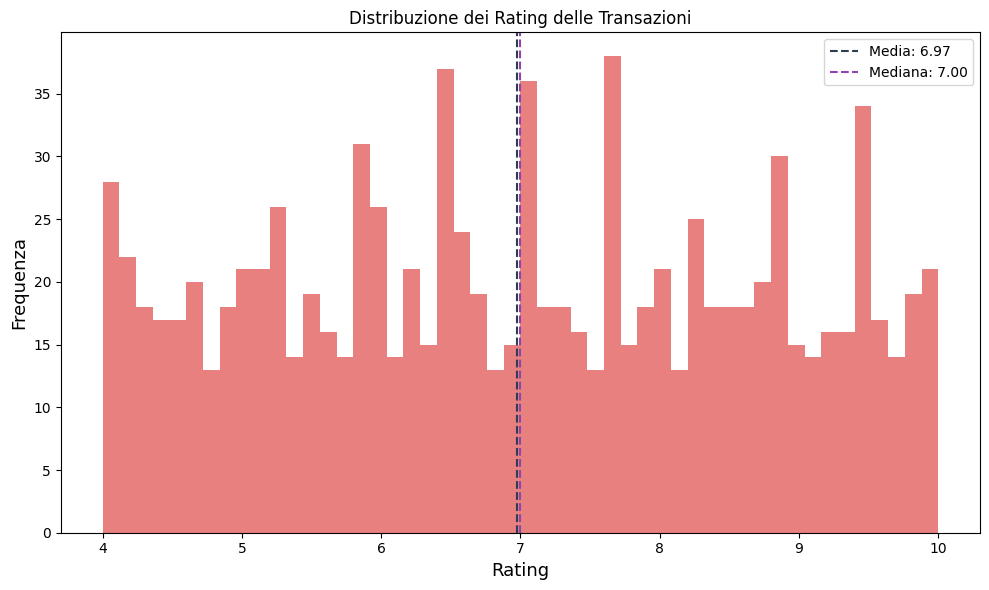

In [10]:

plt.figure(figsize=(10, 6))

plt.hist(regression_dataset['Rating'], bins=50, color='#e88080')

plt.title('Distribuzione dei Rating delle Transazioni')
plt.xlabel('Rating', fontsize=13)
plt.ylabel('Frequenza', fontsize=13)

plt.axvline(regression_dataset['Rating'].mean(), color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Media: {regression_dataset["Rating"].mean():.2f}')
plt.axvline(regression_dataset['Rating'].median(), color='#8e44ad', linestyle='--', linewidth=1.5, label=f'Mediana: {regression_dataset["Rating"].median():.2f}')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

La distribuzione dei rating è più o meno uniforme e non c'è skewness.

La media (6.97) e la mediana (7.00) sono quasi identiche — quando questi due valori coincidono, la distribuzione è simmetrica per definizione
Il grafico mostra che le barre sono distribuite uniformemente da 4 a 10, senza una "coda" più lunga da un lato

Il discorso è  diverso per l'utile lordo ( gross income)

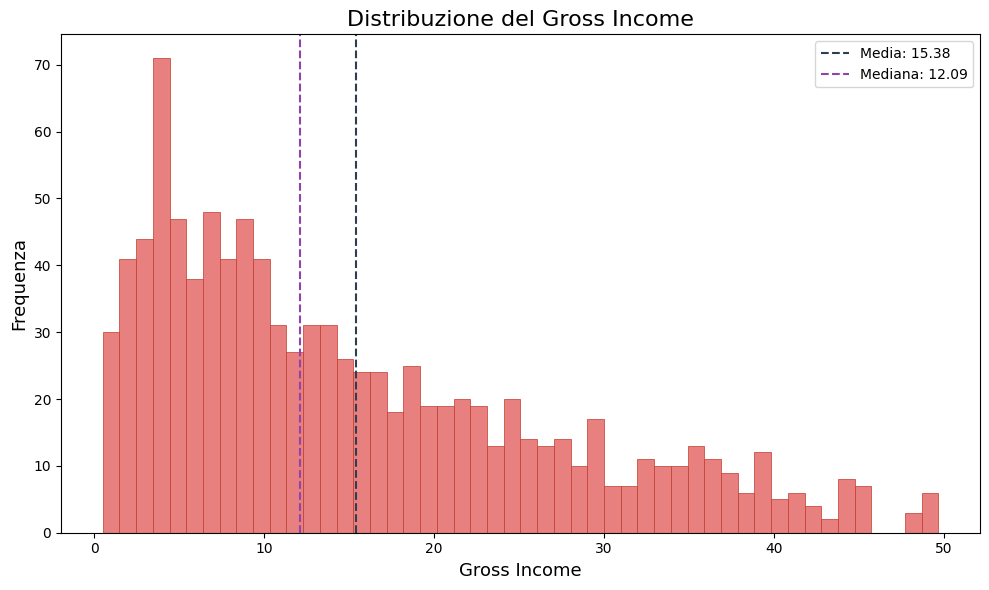

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(regression_dataset['gross income'], bins=50, color='#e88080', edgecolor='#c0392b', linewidth=0.5)

plt.title('Distribuzione del Gross Income', fontsize=16)
plt.xlabel('Gross Income', fontsize=13)
plt.ylabel('Frequenza', fontsize=13)

plt.axvline(regression_dataset['gross income'].mean(), color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Media: {regression_dataset["gross income"].mean():.2f}')
plt.axvline(regression_dataset['gross income'].median(), color='#8e44ad', linestyle='--', linewidth=1.5, label=f'Mediana: {regression_dataset["gross income"].median():.2f}')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

La skewness c'è e la maggioranza degli ordini sembra avere un income lordo basso.

In [12]:
skewness = regression_dataset['gross income'].skew()

print(f"Skewness: {skewness:.2f}")

Skewness: 0.89


skewness positiva (coda a destra).
La maggior parte delle transazioni ha un utile lordo basso (le barre alte sono a sinistra del grafico).
Poche transazioni hanno un utile lordo molto alto (la coda lunga a destra).  il supermercato fa tante vendite piccole e poche vendite molto grandi. La maggior parte degli scontrini è di importo contenuto, con rari acquisti di valore elevato.

# Encoding delle variabili categoriche

Ci sono delle variabili che non sono numeriche.
Utilizzo le tecniche di encoding per trasformarle in vettori.

In [13]:
# codice per effettuare l'encoding delle variabili categoriche

from sklearn.preprocessing import OneHotEncoder
import scipy.sparse

categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
numerical_cols = [c for c in regression_dataset.columns if c not in categorical_cols]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(regression_dataset[categorical_cols])
encoded_cols = ohe.get_feature_names_out(categorical_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=regression_dataset.index)
regression_dataset = pd.concat([regression_dataset[numerical_cols], encoded_df], axis=1)

print(regression_dataset.head())


   Unit price  Quantity  gross income  Rating  Branch_A  Branch_B  Branch_C  \
0       74.69         7       26.1415     9.1       1.0       0.0       0.0   
1       15.28         5        3.8200     9.6       0.0       0.0       1.0   
2       46.33         7       16.2155     7.4       1.0       0.0       0.0   
3       58.22         8       23.2880     8.4       1.0       0.0       0.0   
4       86.31         7       30.2085     5.3       1.0       0.0       0.0   

   City_Mandalay  City_Naypyitaw  City_Yangon  ...  Gender_Male  \
0            0.0             0.0          1.0  ...          0.0   
1            0.0             1.0          0.0  ...          0.0   
2            0.0             0.0          1.0  ...          1.0   
3            0.0             0.0          1.0  ...          1.0   
4            0.0             0.0          1.0  ...          1.0   

   Product line_Electronic accessories  Product line_Fashion accessories  \
0                                  0.0        

# Feature Scaling

Utilizziamo la standardizzazione per "Unit price" e "Gross income" per migliorare la performance dei modelli che andrò a costruire.

In [14]:
# codice per effettuare la standardizzazione della colonna "Unit price" e "gross income"
#StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
regression_dataset[['Unit price', 'gross income']] = scaler.fit_transform(
    regression_dataset[['Unit price', 'gross income']]
)

(regression_dataset[['Unit price', 'gross income']])


,Unit price,gross income
0,0.718160,0.919607
1,-1.525303,-0.987730
2,-0.352781,0.071446
3,0.096214,0.675780
4,1.156959,1.267125
...,...,...
995,-0.578600,-1.141750
996,1.574989,2.846340
997,-0.899958,-1.178109
998,0.383208,-1.032932


# Train e Test Split

Ho utolizzato un ratio 80:20 per lo split fra training e test set.
Le feature di train, le feature di test, la label di train e le label di test sono chiamate con: *X_train*, *X_test*, *y_train* e *y_test*:

In [15]:
from sklearn.model_selection import train_test_split

# codice per splittare il dataset in training set e test set

# Separo le feature dalla label
X = regression_dataset.drop(columns=['Rating'])
y = regression_dataset['Rating']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} righe")
print(f"Test set: {X_test.shape[0]} righe")

Training set: 800 righe
Test set: 200 righe


# Linear Regression

Predire i **Rating** usando il modello più semplice: la linear regression.

In [16]:
from sklearn.linear_model import LinearRegression

# training del modello con la linear regression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("Modello allenato con successo!")

Modello allenato con successo!


Il training è avvenuto, valuto come questo performa. Le metriche che prendo in considerazione sono le principali per la regressione lineare: **il mean squadred error MSE e il mean absolute error MAE**.

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predizioni sul test set
y_pred = regressor.predict(X_test)

# Calcolo delle metriche
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

print('MSE =', MSE, '\nMAE =', MAE)

MSE = 3.110187291026072 
MAE = 1.5229214208487525


# Polynomial Regression



In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Testiamo più gradi per osservare il comportamento delle performance
print(f"{'Grado':<8} {'MSE':<12} {'MAE':<12} {'Note'}")
print("-" * 50)
for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree)
    X_tr_poly = poly.fit_transform(X_train)
    X_te_poly = poly.transform(X_test)

    reg = LinearRegression()
    reg.fit(X_tr_poly, y_train)
    y_pred_poly = reg.predict(X_te_poly)

    mse = mean_squared_error(y_test, y_pred_poly)
    mae = mean_absolute_error(y_test, y_pred_poly)
    note = " migliore" if degree == 2 else ""
    print(f"{degree:<8} {mse:<12.4f} {mae:<12.4f} {note}")

poly_regressor = PolynomialFeatures(degree=3)
X_train_poly = poly_regressor.fit_transform(X_train)
X_test_poly  = poly_regressor.transform(X_test)

regressor_poly = LinearRegression()
regressor_poly.fit(X_train_poly, y_train)
print("\n Modello polinomiale (grado 3) salvato come regressor_poly.")

Grado    MSE          MAE          Note
--------------------------------------------------
2        3.4526       1.5693        migliore
3        5.3594       1.8459       
4        2618.6505    35.1116      
5        241.8786     10.3575      

 Modello polinomiale (grado 3) salvato come regressor_poly.


Le prestazioni peggiorano a causa dell'overfitting. Aumentando il grado, il modello diventa sempre più complesso e inizia ad imparare a memoria i dati di training, incluso il rumore casuale. Il test set performa peggio.
Le feature sono quasi tutte categoriche di conseguenza su questo tipo di dati la Polynomial Regression non porta benefici reali.

Con gradi maggiori la situazione continua a peggiorare. Dal grado 4 in poi MSE e MAE crescono progressivamente. Quindi il grado ottimale è 2  che ha MSE più basso.

Come cambiano le performance? C'è effettivamente un miglioramento nell'MSE e nell'MAE?

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predizioni sul test set
y_pred_poly = regressor_poly.predict(X_test_poly)

# Calcolo delle metriche
MSE_poly = mean_squared_error(y_test, y_pred_poly)
MAE_poly = mean_absolute_error(y_test, y_pred_poly)

print("= Polynomial Regression (grado 3) =")
print(f" MSE = {MSE_poly:.4f}")
print(f" MAE = {MAE_poly:.4f}")

print("\n= Confronto con Linear Regression =")
print(f" MSE migliorato di: {MSE - MSE_poly:.4f}")
print(f" MAE migliorato di: {MAE - MAE_poly:.4f}")
print(f"\n Linear Regression: MSE = {MSE:.4f}, MAE = {MAE:.4f}")
print(f" Poly Regression: MSE = {MSE_poly:.4f}, MAE = {MAE_poly:.4f}")

= Polynomial Regression (grado 3) =
 MSE = 5.3594
 MAE = 1.8459

= Confronto con Linear Regression =
 MSE migliorato di: -2.2492
 MAE migliorato di: -0.3230

 Linear Regression: MSE = 3.1102, MAE = 1.5229
 Poly Regression: MSE = 5.3594, MAE = 1.8459


Si mantiene il modello più semplice (lineare).

Il miglioramento è negativo (-2.25 e -0.32) vuol dire che la regressione polinomiale performa peggio della lineare.

# Logistic Regression

Cambiamo Dataset: ho bisogno di analizzare la classificazione. Si deve valutare la qualità di alcune mele destinate alla catena di supermercati per decidere quali sono le mele di qualità migliore.

Importo il nuovo dataset: ovvero apple_quality, che rinomino classification_dataset.

In [20]:
classification_dataset = pd.read_csv('/content/drive/MyDrive/analitycs /classification_dataset.csv')

print(classification_dataset.head())

   A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0   0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1   1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2   2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3   3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4   4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   

        Acidity Quality  
0  -0.491590483    good  
1  -0.722809367    good  
2   2.621636473     bad  
3   0.790723217    good  
4   0.501984036    good  


In [21]:
classification_dataset.head(50)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
5,5.0,-3.425400,-1.409082,-1.913511,-0.555775,-3.853071,1.914616,-2.981523169,bad
6,6.0,1.331606,1.635956,0.875974,-1.677798,3.106344,-1.847417,2.414170509,good
7,7.0,-1.995462,-0.428958,1.530644,-0.742972,0.158834,0.974438,-1.470125066,good
8,8.0,-3.867632,-3.734514,0.986429,-1.207655,2.292873,4.080921,-4.871904758,bad
9,9.0,-0.727983,-0.442820,-4.092223,0.597513,0.393714,1.620857,2.185607723,bad


Analizziamo i metadati delle colonne del dataset:

In [22]:
classification_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


In [23]:
# Rimuovi la riga anomala di Acidity
classification_dataset = classification_dataset[pd.to_numeric(classification_dataset['Acidity'], errors='coerce').notna()]
classification_dataset['Acidity'] = classification_dataset['Acidity'].astype(float)
print(classification_dataset.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(8), object(1)
memory usage: 312.5+ KB
None


Il dataset è già pulito e quasi tutte le colonne sono numeriche. L'unica a non esserlo è proprio la label Quality, che vado a encodare:

In [24]:
# Encoding della label QUALITY
classification_dataset['Quality'] = classification_dataset['Quality'].map({'good': 1, 'bad': 0})

print(classification_dataset['Quality'].unique())

[1 0]


In [25]:
classification_dataset.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,1
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,1
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,0
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,1
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,1


Ri-effettuo la divisione fra porzione di addestramento e porzione di test, usando la nomenclatura già vista.

In [26]:
# codice per splittare in train/test il dataset apple_quality

X = classification_dataset.drop(columns=['Quality'])
y = classification_dataset['Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} righe")
print(f"Test set: {X_test.shape[0]} righe")

Training set: 3200 righe
Test set: 800 righe


Uso la logistic regression per allenare il modello vero e proprio, chiamandolo *logistic_regressor*:

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as ScalerLR
from sklearn.model_selection import GridSearchCV

# Scalo le feature
scaler_lr = ScalerLR()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled  = scaler_lr.transform(X_test)

# GridSearchCV per trovare il miglior C
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid,
    scoring='f1_macro',
    cv=5
)
grid_search.fit(X_train_scaled, y_train)

logistic_regressor = grid_search.best_estimator_
print(f"Miglior C trovato: {grid_search.best_params_['C']}")
print(f"F1-macro (cross-validation): {grid_search.best_score_:.4f}")
print("Modello allenato con successo.")

Miglior C trovato: 1
F1-macro (cross-validation): 0.7416
Modello allenato con successo.


Una metrica che ti permette subito di valutare la bontà del modello è l'***F1 score***, che dovrebbe essere idealmente superiore a 0.80.

In [28]:
from sklearn.metrics import classification_report, f1_score

# Otteniamo le probabilità invece delle predizioni binarie
y_proba = logistic_regressor.predict_proba(X_test_scaled)[:, 1]

# il threshold ottimale che massimizza F1-macro
thresholds = np.arange(0.30, 0.71, 0.01)
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int), average='macro') for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Threshold ottimale trovato: {best_thresh:.2f}  (F1-macro = {max(f1_scores):.4f})")
print()

# Predizioni finali con il threshold ottimale
y_predict_test = (y_proba >= best_thresh).astype(int)

print(classification_report(y_test, y_predict_test))

Threshold ottimale trovato: 0.47  (F1-macro = 0.7612)

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       401
           1       0.75      0.78      0.77       399

    accuracy                           0.76       800
   macro avg       0.76      0.76      0.76       800
weighted avg       0.76      0.76      0.76       800



Visualizziamo la ROC curve per interpretare graficamente le diverse soglie che abbiamo testato.

 La curva mostra come cambia il rapporto tra True Positive Rate e False Positive Rate al variare della soglia decisionale.

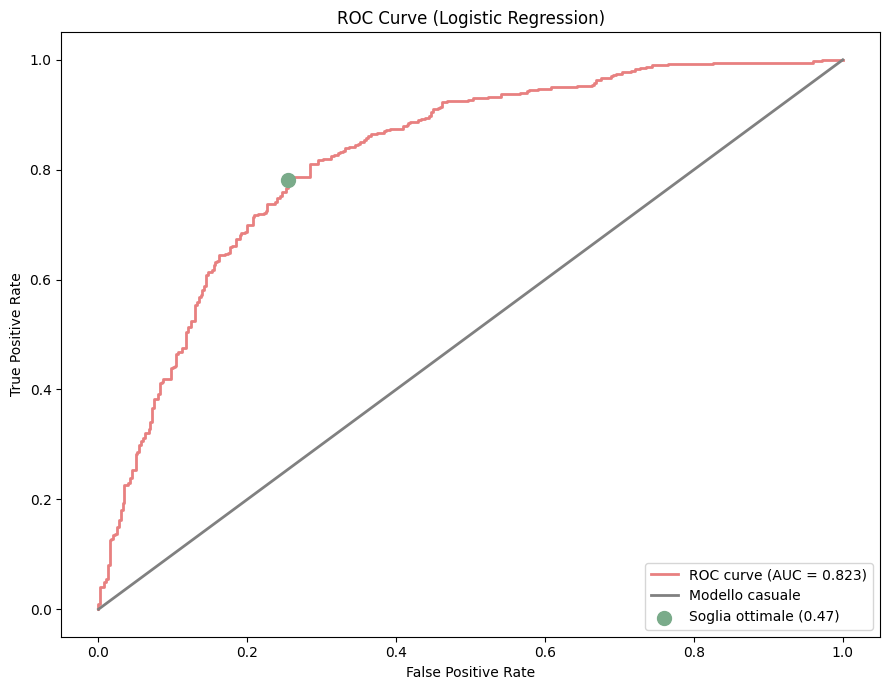

AUC = 0.8228


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# i valori per la ROC curve
fpr, tpr, soglie = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

#punto sulla curva corrispondente alla soglia ottimale
distanze = abs(soglie - best_thresh)
idx_best = distanze.argmin()

plt.figure(figsize=(9, 7))

# Curva ROC
plt.plot(fpr, tpr, color='#e88080', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')

# Linea di riferimento (modello casuale)
plt.plot([0, 1], [0, 1], color='gray', linestyle='-', linewidth=2, label='Modello casuale')

# Punto della soglia ottimale
plt.scatter(fpr[idx_best], tpr[idx_best], color='#7aab8a', zorder=5, s=100,
            label=f'Soglia ottimale ({best_thresh:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC = {auc:.4f}")

La ROC curve mostra un AUC di 0.82, indica buone performance del modello. La soglia ottimale di 0.47 (punto verde) è quella che massimizza l'F1-macro, bilanciando correttamente le due classi.
Un AUC vicino a 1 indica un modello che distingue bene le classi.

La **confusion matrix**, mostra quali sono le categorie su cui il modello che ho costruito è "bravo" e su quali no, così da eventualmente avere delle informazioni in più per migliorarlo.

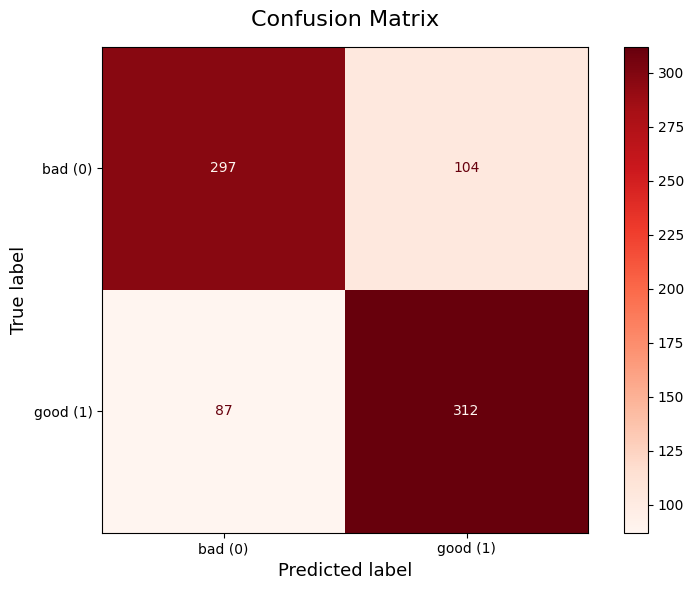

In [29]:
# codice per la confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predict_test)

# Visualizzazione
# Visualizzazione
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad (0)', 'good (1)'])
disp.plot(cmap='Reds', ax=ax)

ax.set_title('Confusion Matrix', fontsize=16, pad=15)
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)

plt.tight_layout()
plt.show()

Confusion Matrix:

297 mele realmente 'bad' predette correttamente come bad.
312 mele realmente 'good' predette correttamente come good.
Fuori la diagonale sono Falsi Negativi (87 e 104), cioè predizioni sbagliate.
Su 800 mele totali del test set, il modello ne ha indovinate 609 e sbagliate 191 (87+104), per un'accuratezza di circa 75%.
Il modello è leggermente più bravo ma la differenza non è enorme, quindi performa in modo abbastanza equilibrato sulle due classi.

# Decision Tree

Utilizzo un decision tree per capire se è possibile migliorare le prestazioni del modello basato su logistic regression.

In [30]:
# training del modello con un decision tree usando GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=5
)
grid_search_dt.fit(X_train, y_train)

decision_tree = grid_search_dt.best_estimator_
print(f"Migliori parametri: {grid_search_dt.best_params_}")
print(f"F1-macro (cross-validation): {grid_search_dt.best_score_:.4f}")
print("Decision Tree allenato con successo.")

Migliori parametri: {'max_depth': None, 'min_samples_split': 2}
F1-macro (cross-validation): 0.7981
Decision Tree allenato con successo.


=== Classification Report - Decision Tree (ottimizzato) ===
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       401
           1       0.82      0.80      0.81       399

    accuracy                           0.81       800
   macro avg       0.81      0.81      0.81       800
weighted avg       0.81      0.81      0.81       800



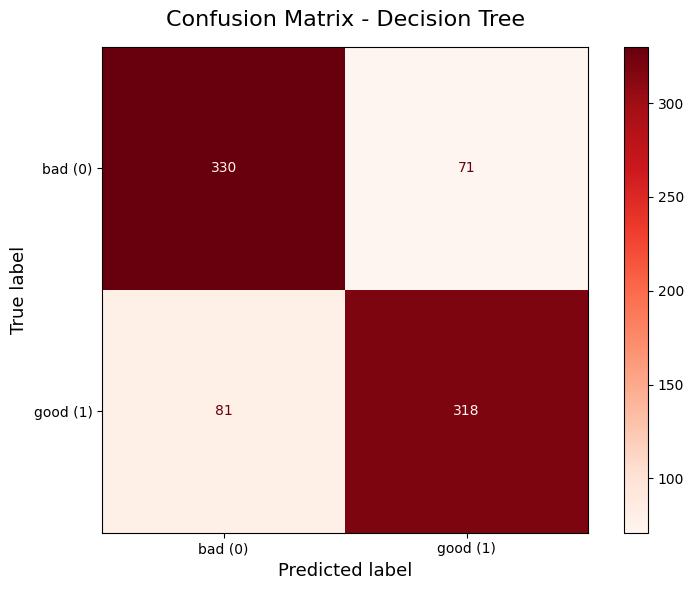

In [31]:
# confusion matrix del decision tree
from sklearn.metrics import classification_report

y_predict_tree = decision_tree.predict(X_test)

print("=== Classification Report - Decision Tree (ottimizzato) ===")
print(classification_report(y_test, y_predict_tree))

cm_tree = confusion_matrix(y_test, y_predict_tree)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['bad (0)', 'good (1)'])
disp.plot(cmap='Reds', ax=ax)

ax.set_title('Confusion Matrix - Decision Tree', fontsize=16, pad=15)
ax.xaxis.label.set_fontsize(13)
ax.yaxis.label.set_fontsize(13)

plt.tight_layout()
plt.show()

Decision Tree ottimizzato:

330 mele realmente bad predette correttamente come bad.
318 mele realmente good predette correttamente come good.

Su 800 mele totali del test set, il modello ne ha indovinate 648 e sbagliate 152, per un'accuratezza dell'82%.

Confronto con la Logistic Regression:
Il Decision Tree ottimizzato migliora rispetto alla Logistic Regression che ha il 75% di accuratezza.

Le due classi sono bilanciate:

F1-score bad: 0.82

F1-score good: 0.81

I valori sono molto simili tra loro, il modello performa in modo equilibrato su entrambe le classi.

In [32]:
# codice per la feature importance

feature_importance = pd.Series(decision_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

print(feature_importance)

Ripeness       0.196000
Size           0.159773
Sweetness      0.155163
Acidity        0.129963
Juiciness      0.126133
Weight         0.091596
Crunchiness    0.090582
A_id           0.050790
dtype: float64


Le feature più importanti per il Decision Tree:

Top 3 più importanti:
- Ripeness (0.196): la maturazione è la caratteristica più determinante per stabilire la qualità di una mela — ha senso, una mela troppo acerba o troppo matura è di bassa qualità
- Size (0.160): la dimensione è il secondo fattore più importante
- Sweetness (0.155)

I valori sono abbastanza distribuiti uniformemente tra le feature (nessuna domina le altre) quindi il modello usa tutte le caratteristiche per prendere le sue decisioni.

# K-Means Clustering

Il più utilizzato algoritimo tra quelli non supervisionati.

Bisogna eliminare la label: il K-Means Clustering è un algoritmo non supervisionato e non deve quindi averla:

In [33]:
from sklearn.preprocessing import StandardScaler

clustering_dataset = classification_dataset.drop(columns=['Quality'])

# StandardScaler: necessario per K-Means
scaler_km = StandardScaler()
clustering_dataset_scaled = scaler_km.fit_transform(clustering_dataset)
print("Feature scalate con StandardScaler. Shape:", clustering_dataset_scaled.shape)

Feature scalate con StandardScaler. Shape: (4000, 8)


Setto il modello usando l'algoritmo in oggetto.

Prima prova: settare il numero dei cluster a due (in quanto sappiamo che il dataset contiene mele buone o non buone):

In [34]:
# codice per trainare il modello con K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(clustering_dataset_scaled)  # usiamo i dati scalati

print("Cluster assegnati:", kmeans.labels_)
print("Convergenza raggiunta in", kmeans.n_iter_, "iterazioni")

Cluster assegnati: [0 0 1 ... 0 0 1]
Convergenza raggiunta in 49 iterazioni


Effettua quindi una predizione e vedi a che qualità corrisponde la mela che hai dato in input al modello:

In [35]:
# codice per effettuare la predizione su una mela dalle carattetistiche a piacere

mela = pd.DataFrame([[5.0, 3.0, 7.0, 6.0, 4.0, 5.0, 3.0, 2.0]], columns=clustering_dataset.columns)

# La mela va scalata con lo stesso scaler usato in fase di training
mela_scaled = scaler_km.transform(mela)

cluster = kmeans.predict(mela_scaled)
print(f"La mela è stata assegnata al cluster: {cluster[0]}")

print(f"\nCluster 0 = {classification_dataset[kmeans.labels_ == 0]['Quality'].value_counts().idxmax()}")
print(f"Cluster 1 = {classification_dataset[kmeans.labels_ == 1]['Quality'].value_counts().idxmax()}")

La mela è stata assegnata al cluster: 1

Cluster 0 = 0
Cluster 1 = 1


La mela è stata assegnata al Cluster 1, quindi è stata classificata come bad dal K-Means.

Seconda prova: settare il numero di cluster a tre e testare questo scenario.

In [36]:
# K-Means con 3 cluster (dati scalati)
kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans3.fit(clustering_dataset_scaled)

# Stessa mela di prima (già scalata)
cluster3 = kmeans3.predict(mela_scaled)
print(f"La mela è stata assegnata al cluster: {cluster3[0]}")

# Distribuzione delle qualità per ogni cluster
for i in range(3):
    print(f"\nCluster {i}:")
    print(classification_dataset[kmeans3.labels_ == i]['Quality'].value_counts())

La mela è stata assegnata al cluster: 0

Cluster 0:
Quality
1    602
0    389
Name: count, dtype: int64

Cluster 1:
Quality
1    770
0    733
Name: count, dtype: int64

Cluster 2:
Quality
0    874
1    632
Name: count, dtype: int64


La mela è stata assegnata al cluster 0: prevalentemente bad.

**Ricordiamo: 0 Good, 1 Bad**

Cosa ci dicono i 3 cluster:

Cluster 0 prevalentemente bad

Cluster 1 misto (50/50)

Cluster 2 prevalentemente good

Cosa significa:
Con 3 cluster si trova la terza categoria intermedia il Cluster 1 ha il 50/50 di quantità di mele bad e good, rappresenta le mele di qualità media.

Da notare che i tre cluster non sono esattamente separati — in tutti e tre ci sono sia mele good che bad in proporzioni simili. Questo ci dice che con 3 cluster il K-Means fa più fatica a distinguere la qualità delle mele.

Visualizziamo i cluster ottenuti con K-Means usando la PCA per ridurre la dimensionalità del dataset a 2 componenti: è possibile vederli in modo bidimensionale.

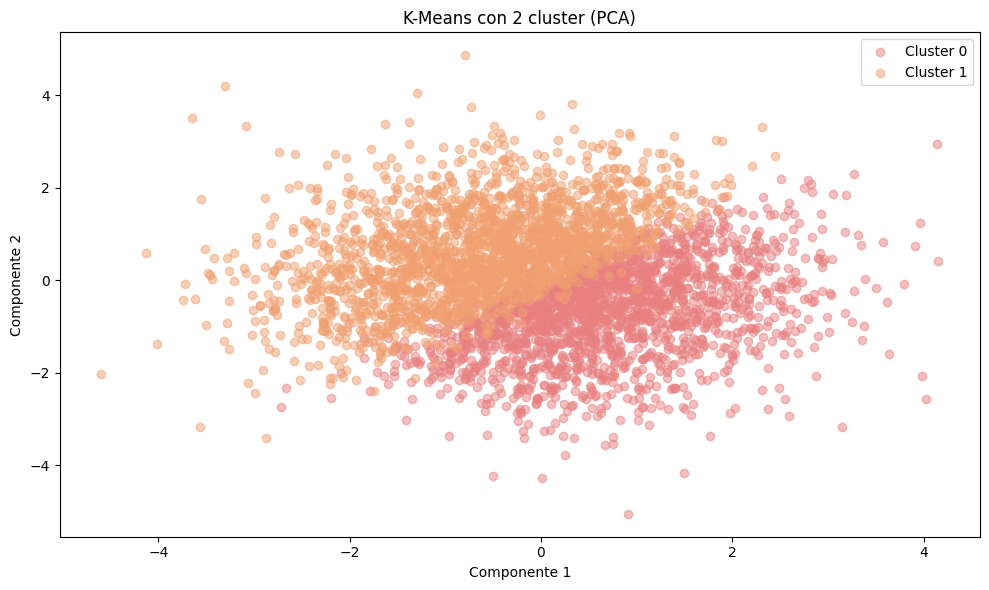

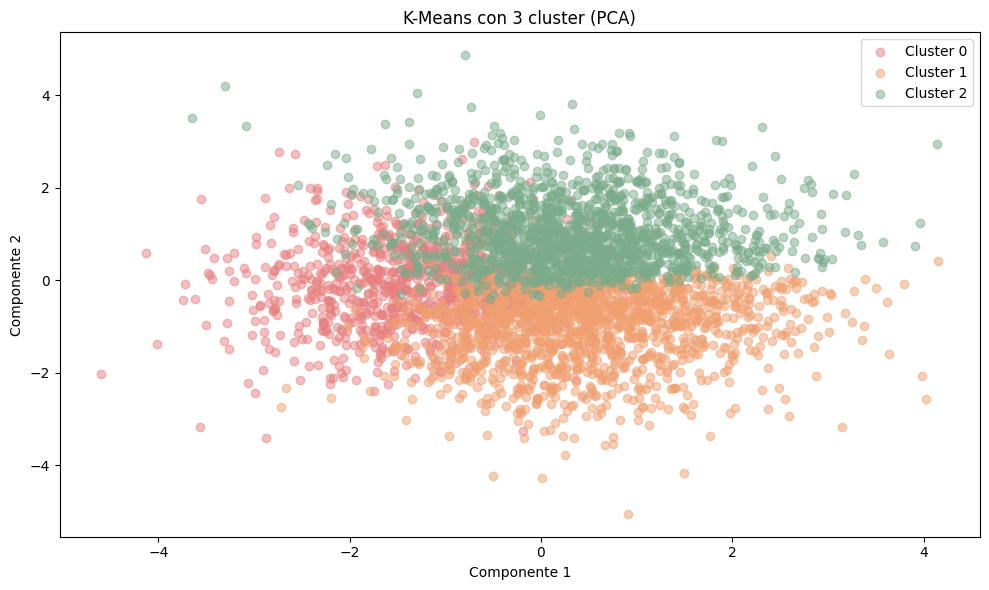

In [37]:
# Visualizzazione dei cluster con PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Riduciamo le feature a 2 dimensioni con PCA
pca = PCA(n_components=2)
dati_2d = pca.fit_transform(clustering_dataset_scaled)

# Grafico per kmeans con 2 cluster
plt.figure(figsize=(10, 6))
colori = ['#e88080', '#f0a070']
for cluster_id in range(2):
    punti = dati_2d[kmeans.labels_ == cluster_id]
    plt.scatter(punti[:, 0], punti[:, 1], c=colori[cluster_id], label=f'Cluster {cluster_id}', alpha=0.5)

plt.title('K-Means con 2 cluster (PCA)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.tight_layout()
plt.show()

# Grafico per kmeans con 3 cluster
plt.figure(figsize=(10, 6))
colori3 = ['#e88080', '#f0a070', '#7aab8a']
for cluster_id in range(3):
    punti = dati_2d[kmeans3.labels_ == cluster_id]
    plt.scatter(punti[:, 0], punti[:, 1], c=colori3[cluster_id], label=f'Cluster {cluster_id}', alpha=0.5)

plt.title('K-Means con 3 cluster (PCA)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.tight_layout()
plt.show()

La visualizzazione PCA sottolinea che i cluster non sono separabili nettamente. C'è molta sovrapposizione.

# Time Series

Per capire come i gross income evolvono nel tempo, andiamo ad analizzare il dataset originale, ovvero *regression_raw_dataset* eliminando tutte le colonne tranne  "Date" e "gross income" assegnando il nome *timeseries_dataset* al nuovo dataset:

In [38]:
# codice per costruire un nuovo dataset, partendo da regression_raw_dataset, con solo le colonne "Date" e "gross income"

timeseries_dataset = regression_raw_dataset[['Date', 'gross income']].copy()

In [39]:
timeseries_dataset.head(100)

,Date,gross income
0,1/5/2019,26.1415
1,3/8/2019,3.8200
2,3/3/2019,16.2155
3,1/27/2019,23.2880
4,2/8/2019,30.2085
...,...,...
95,3/8/2019,4.8580
96,3/29/2019,43.9350
97,2/9/2019,3.7350
98,3/23/2019,7.9125


 **linear regression** su questa serie temporale.

In [40]:
# training della time series con la linear regression

# Convertiamo la data in un numero utilizzabile dal modello
timeseries_dataset['Date'] = pd.to_datetime(timeseries_dataset['Date'])
timeseries_dataset['Date_ordinal'] = timeseries_dataset['Date'].map(pd.Timestamp.toordinal)

X_ts = timeseries_dataset[['Date_ordinal']]
y_ts = timeseries_dataset['gross income']

X_ts_train, X_ts_test, y_ts_train, y_ts_test = train_test_split(X_ts, y_ts, test_size=0.2, random_state=42)

regressor_ts = LinearRegression()
regressor_ts.fit(X_ts_train, y_ts_train)

print("Modello Time Series allenato con successo.")

Modello Time Series allenato con successo.


Controllo MSE ed MAE:

In [41]:
# MSE e MAE
y_ts_pred = regressor_ts.predict(X_ts_test)

MSE = mean_squared_error(y_ts_test, y_ts_pred)
MAE = mean_absolute_error(y_ts_test, y_ts_pred)


print('MSE =', MSE, '\nMAE =', MAE)

MSE = 148.88068801884722 
MAE = 9.977287707645043


Il problema della regressione lineare sulle time series:
Il gross income nel tempo ha oscillazioni, stagionalità, picchi casuali. La regressione lineare cerca per forza una retta e quindi non tiene in considerazioni le caratteristiche descritte ma predice valori vicino alla media.
MSE e MAE non sono elevati come in precedenza perchè il modello sta predicendo sopra la media, ma non sta imparando nulla di utile sul trend temporale.